In [1]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import h5py
import soundfile as sf
import matplotlib.pyplot as plt

from scipy.signal import spectrogram
from tqdm.auto import tqdm

# 1. Setup

In [2]:
BASE_DIR = Path.cwd() / "yang_long_2025_budgie_aac"
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = BASE_DIR / "processed"
OUT_DIR = BASE_DIR / "model_ready_all_parrots"

OUT_DIR.mkdir(parents=True, exist_ok=True)

BIRDS = [
    "Bl122_ChronicLeftAAC",
    "Li145_ChronicLeftAAC",
    "Or61_ChronicLeftAAC",
    "Ti81_ChronicLeftAAC",
]

# Start with 10 min debug. Later set to 1800 for 30 min.
MAX_DURATION_SEC = 600

OUT_H5 = OUT_DIR / f"all_parrots_audioX_spikesY_wideband_{MAX_DURATION_SEC // 60}min.h5"

FS = 30000

# STFT settings
STFT_WINDOW_SEC = 0.02
STFT_STEP_SEC = 0.001
NFFT = 1024

# Wideband frequency range
FREQ_MIN_HZ = 300
FREQ_MAX_HZ = 14500

# Spike alignment
SPIKE_BIN_SEC = STFT_STEP_SEC
MOTOR_DELAY_SEC = 0.012

OVERWRITE = True

print("OUT_H5:", OUT_H5)

OUT_H5: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/model_ready_all_parrots/all_parrots_audioX_spikesY_wideband_10min.h5


# 2. build aligned data
X = audio spectrogram\
Y = spikes

In [3]:
def get_paths(bird):
    return {
        "audio": DATA_DIR / bird / "audioCh3_HP.flac",
        "spikes": PROCESSED_DIR / bird / "spikes.h5",
    }


def load_spike_list(spikes_h5):
    spike_list = []

    with h5py.File(spikes_h5, "r") as h5:
        spike_times = h5["spike_times_sec"]
        ptr = h5["unit_ptr"][:]

        for u in range(len(ptr) - 1):
            spike_list.append(spike_times[ptr[u]:ptr[u + 1]])

    return spike_list


def read_audio(audio_path, max_duration_sec):
    info = sf.info(str(audio_path))
    assert info.samplerate == FS

    stop = info.frames
    if max_duration_sec is not None:
        stop = min(stop, int(round(max_duration_sec * FS)))

    audio, fs = sf.read(
        str(audio_path),
        start=0,
        stop=stop,
        always_2d=False,
    )

    if audio.ndim > 1:
        audio = audio[:, 0]

    return audio.astype(np.float32), fs, info.frames / fs


def make_spectrogram(audio, fs):
    """
    X_audio[t, f] = 20 log10 |STFT(audio)|

    Time step = 1 ms.
    Frequency range = 300–14500 Hz.
    """
    nperseg = int(round(STFT_WINDOW_SEC * fs))
    hop = int(round(STFT_STEP_SEC * fs))
    noverlap = nperseg - hop

    freq, time, mag = spectrogram(
        audio,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=NFFT,
        detrend=False,
        scaling="spectrum",
        mode="magnitude",
    )

    keep = (freq >= FREQ_MIN_HZ) & (freq <= FREQ_MAX_HZ)
    X_audio = 20 * np.log10(mag[keep].T + 1e-12)

    return (
        X_audio.astype(np.float32),
        time.astype(np.float64),
        freq[keep].astype(np.float32),
    )


def bin_spikes_on_audio_grid(spike_list, audio_time):
    """
    X_audio[k] is at audio time t_k.
    Y_spikes[k] counts spikes around t_k - MOTOR_DELAY_SEC.
    """
    neural_time = audio_time - MOTOR_DELAY_SEC
    half = SPIKE_BIN_SEC / 2

    valid = neural_time - half >= 0

    audio_time_valid = audio_time[valid]
    neural_time_valid = neural_time[valid]

    edges = np.concatenate([
        neural_time_valid - half,
        [neural_time_valid[-1] + half],
    ])

    Y = np.zeros((len(neural_time_valid), len(spike_list)), dtype=np.uint16)

    for u, st in enumerate(spike_list):
        left = np.searchsorted(st, edges[0], side="left")
        right = np.searchsorted(st, edges[-1], side="right")
        Y[:, u] = np.histogram(st[left:right], bins=edges)[0]

    return Y, audio_time_valid, valid


if OUT_H5.exists() and OVERWRITE:
    OUT_H5.unlink()


with h5py.File(OUT_H5, "w") as h5:
    h5.attrs["meaning"] = (
        "X_audio[t] = wideband STFT amplitude spectrogram at audio time t; "
        "Y_spikes[t] = spike counts around audio time t - motor_delay_sec"
    )

    h5.attrs["fs"] = FS
    h5.attrs["stft_window_sec"] = STFT_WINDOW_SEC
    h5.attrs["stft_step_sec"] = STFT_STEP_SEC
    h5.attrs["nfft"] = NFFT
    h5.attrs["freq_min_hz"] = FREQ_MIN_HZ
    h5.attrs["freq_max_hz"] = FREQ_MAX_HZ
    h5.attrs["spike_bin_sec"] = SPIKE_BIN_SEC
    h5.attrs["motor_delay_sec"] = MOTOR_DELAY_SEC
    h5.attrs["max_duration_sec"] = -1 if MAX_DURATION_SEC is None else MAX_DURATION_SEC

    for bird_id, bird in enumerate(BIRDS):
        print("\n" + "=" * 80)
        print(bird)

        paths = get_paths(bird)

        audio, fs, raw_duration_sec = read_audio(paths["audio"], MAX_DURATION_SEC)
        X_audio, audio_time, freq_hz = make_spectrogram(audio, fs)

        spike_list = load_spike_list(paths["spikes"])
        Y_spikes, audio_time_valid, valid = bin_spikes_on_audio_grid(
            spike_list,
            audio_time,
        )

        X_audio = X_audio[valid]

        grp = h5.create_group(bird)

        grp.attrs["bird_id"] = bird_id
        grp.attrs["n_units"] = Y_spikes.shape[1]
        grp.attrs["raw_duration_sec"] = raw_duration_sec
        grp.attrs["used_duration_sec"] = len(audio) / fs

        grp.create_dataset("X_audio", data=X_audio, compression="lzf")
        grp.create_dataset("Y_spikes", data=Y_spikes, compression="lzf")
        grp.create_dataset("time_audio_sec", data=audio_time_valid, compression="lzf")
        grp.create_dataset("freq_hz", data=freq_hz)

        print("raw duration min:", raw_duration_sec / 60)
        print("used duration min:", len(audio) / fs / 60)
        print("freq range:", freq_hz[0], freq_hz[-1])
        print("n freq bins:", len(freq_hz))
        print("X_audio:", X_audio.shape, X_audio.dtype)
        print("Y_spikes:", Y_spikes.shape, Y_spikes.dtype)

        del audio, X_audio, Y_spikes, audio_time, audio_time_valid, spike_list
        gc.collect()

print("\nSaved:", OUT_H5)


Bl122_ChronicLeftAAC
raw duration min: 270.0
used duration min: 10.0
freq range: 322.26562 14472.656
n freq bins: 484
X_audio: (599978, 484) float32
Y_spikes: (599978, 43) uint16

Li145_ChronicLeftAAC
raw duration min: 281.1123911111111
used duration min: 10.0
freq range: 322.26562 14472.656
n freq bins: 484
X_audio: (599978, 484) float32
Y_spikes: (599978, 81) uint16

Or61_ChronicLeftAAC
raw duration min: 33.016666666666666
used duration min: 10.0
freq range: 322.26562 14472.656
n freq bins: 484
X_audio: (599978, 484) float32
Y_spikes: (599978, 47) uint16

Ti81_ChronicLeftAAC
raw duration min: 330.0
used duration min: 10.0
freq range: 322.26562 14472.656
n freq bins: 484
X_audio: (599978, 484) float32
Y_spikes: (599978, 49) uint16

Saved: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/model_ready_all_parrots/all_parrots_audioX_spikesY_wideband_10min.h5


# 3. read as numpy

In [4]:
with h5py.File(OUT_H5, "r") as h5:
    print("H5:", OUT_H5)
    print("attrs:")
    for k, v in h5.attrs.items():
        print(f"  {k}: {v}")

    rows = []

    for bird in BIRDS:
        g = h5[bird]

        rows.append({
            "bird": bird,
            "X_audio_shape": tuple(g["X_audio"].shape),
            "Y_spikes_shape": tuple(g["Y_spikes"].shape),
            "freq_min": float(g["freq_hz"][0]),
            "freq_max": float(g["freq_hz"][-1]),
            "n_freq": len(g["freq_hz"]),
            "used_duration_min": float(g.attrs["used_duration_sec"]) / 60,
            "raw_duration_min": float(g.attrs["raw_duration_sec"]) / 60,
            "n_units": int(g.attrs["n_units"]),
        })

summary_df = pd.DataFrame(rows)
display(summary_df)

H5: /home/ganchao/Desktop/audio_convergent/yang_long_2025_budgie_aac/model_ready_all_parrots/all_parrots_audioX_spikesY_wideband_10min.h5
attrs:
  freq_max_hz: 14500
  freq_min_hz: 300
  fs: 30000
  max_duration_sec: 600
  meaning: X_audio[t] = wideband STFT amplitude spectrogram at audio time t; Y_spikes[t] = spike counts around audio time t - motor_delay_sec
  motor_delay_sec: 0.012
  nfft: 1024
  spike_bin_sec: 0.001
  stft_step_sec: 0.001
  stft_window_sec: 0.02


,bird,X_audio_shape,Y_spikes_shape,freq_min,freq_max,n_freq,used_duration_min,raw_duration_min,n_units
0,Bl122_ChronicLeftAAC,"(599978, 484)","(599978, 43)",322.265625,14472.65625,484,10.0,270.000000,43
1,Li145_ChronicLeftAAC,"(599978, 484)","(599978, 81)",322.265625,14472.65625,484,10.0,281.112391,81
2,Or61_ChronicLeftAAC,"(599978, 484)","(599978, 47)",322.265625,14472.65625,484,10.0,33.016667,47
3,Ti81_ChronicLeftAAC,"(599978, 484)","(599978, 49)",322.265625,14472.65625,484,10.0,330.000000,49


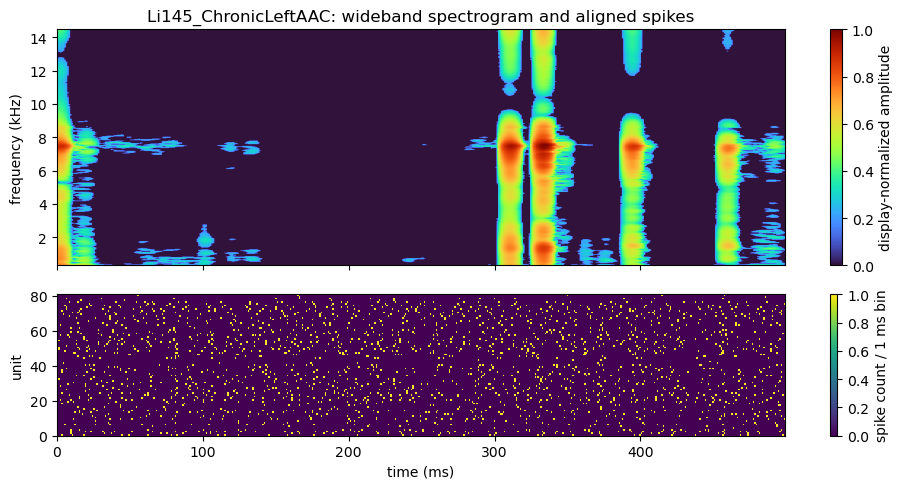

In [5]:
def display_spectrogram(S, clamp_frac=0.20, dynamic_range_db=70):
    """
    Display only.
    Clamp weak background for cleaner sonogram.
    """
    S = S.copy()

    S_rel = S - np.max(S)
    S = (S_rel + dynamic_range_db) / dynamic_range_db
    S = np.clip(S, 0, 1)

    S[S < clamp_frac] = 0

    return S


def find_representative_window_h5(bird, duration_sec=0.5):
    win = int(round(duration_sec / STFT_STEP_SEC))

    with h5py.File(OUT_H5, "r") as h5:
        X = h5[bird]["X_audio"]
        n = X.shape[0]

        best_i = 0
        best_score = -np.inf

        for i in range(0, n - win, win):
            chunk = X[i:i + win]
            score = np.percentile(chunk, 99.5)

            if score > best_score:
                best_score = score
                best_i = i

    return best_i, best_i + win


def plot_representative_period_h5(bird="Li145_ChronicLeftAAC", duration_sec=0.5):
    i0, i1 = find_representative_window_h5(bird, duration_sec)

    with h5py.File(OUT_H5, "r") as h5:
        X = h5[bird]["X_audio"][i0:i1]
        Y = h5[bird]["Y_spikes"][i0:i1]
        t = h5[bird]["time_audio_sec"][i0:i1]
        f = h5[bird]["freq_hz"][:]

    X_show = display_spectrogram(X, clamp_frac=0.20)
    t_ms = (t - t[0]) * 1000

    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 5),
        sharex=True,
        gridspec_kw={"height_ratios": [2.0, 1.2]},
    )

    im0 = axes[0].imshow(
        X_show.T,
        origin="lower",
        aspect="auto",
        cmap="turbo",
        vmin=0,
        vmax=1,
        extent=[t_ms[0], t_ms[-1], f[0] / 1000, f[-1] / 1000],
    )
    axes[0].set_ylabel("frequency (kHz)")
    axes[0].set_title(f"{bird}: wideband spectrogram and aligned spikes")
    fig.colorbar(im0, ax=axes[0], label="display-normalized amplitude")

    im1 = axes[1].imshow(
        Y.T,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        extent=[t_ms[0], t_ms[-1], 0, Y.shape[1]],
    )
    axes[1].set_ylabel("unit")
    axes[1].set_xlabel("time (ms)")
    fig.colorbar(im1, ax=axes[1], label="spike count / 1 ms bin")

    plt.tight_layout()
    plt.show()


plot_representative_period_h5("Li145_ChronicLeftAAC", duration_sec=0.5)